# Loading Dataset 
Using JSON file


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain

# === Paths ===
BASE_DIR = r"C:\Users\marco\OneDrive\Ambiente de Trabalho\Tese\Dataset\XML Dataset"
JSON_PATH = os.path.join(BASE_DIR, "bgg_metadata_final.json")

# Output directory for EDA artifacts
EDA_DIR = os.path.join(BASE_DIR, "eda_outputs")
os.makedirs(EDA_DIR, exist_ok=True)

# === Load dataset ===
df = pd.read_json(JSON_PATH)

print(f"Shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
df.head(3)


Shape: (166942, 9)

Columns: ['id', 'name', 'description', 'type', 'geek_type', 'categories', 'mechanisms', 'families', 'implements']


,id,name,description,type,geek_type,categories,mechanisms,families,implements
0,224517,Brass: Birmingham,Brass: Birmingham is an economic strategy game...,boardgame,Strategy,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Cities: Birmingham (England), Components: Map ...","Brass: Pittsburgh, Brass: Lancashire"
1,161936,Pandemic Legacy: Season 1,Pandemic Legacy is a co-operative campaign gam...,boardgame,Thematic,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Components: Map (Global Scale), Components: Mu...","Pandemic Legacy: Season 2, Pandemic"
2,342942,Ark Nova,"In Ark Nova, you will plan and design a modern...",boardgame,Strategy,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...","Animals: Okapi, Components: Hexagonal Tiles, C...",Sanctuary


# Data Quality Overview

In [2]:
# Duplicates
print("Duplicate rows by ID:", df.duplicated(subset=["id"]).sum())

# Missing values
missing = df.isna().mean().sort_values(ascending=False) * 100
print("\nMissing values (%):")
print(missing)

# Basic record counts
print("\nGames without description:", (df["description"].isna() | (df["description"] == "")).sum())
print("Games without mechanics:", df["mechanisms"].isna().sum())
print("Games without categories:", df["categories"].isna().sum())


Duplicate rows by ID: 0

Missing values (%):
id             0.0
name           0.0
description    0.0
type           0.0
geek_type      0.0
categories     0.0
mechanisms     0.0
families       0.0
implements     0.0
dtype: float64

Games without description: 39
Games without mechanics: 0
Games without categories: 0


Cleaning 'Empty description' Games

In [3]:
df = df[df["description"].notna() & df["description"].str.strip().ne("")]
print("Remaining games:", len(df))
print("Empty descriptions:", (df["description"].isna() | (df["description"].str.strip() == "")).sum())


Remaining games: 166903
Empty descriptions: 0


# Multi-Label Parsing (Geek Type, Categories, Mechanisms)

In [5]:
def to_list(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(",") if i.strip()]

for col in ["geek_type", "categories", "mechanisms"]:
    if col in df.columns:
        df[col + "_list"] = df[col].apply(to_list)

# Count how many items per label type
df["n_geektypes"] = df["geek_type_list"].apply(len)
df["n_categories"] = df["categories_list"].apply(len)
df["n_mechanisms"] = df["mechanisms_list"].apply(len)

df[["id", "name", "n_geektypes", "n_categories", "n_mechanisms"]].head()


,id,name,n_geektypes,n_categories,n_mechanisms
0,224517,Brass: Birmingham,1,6,14
1,161936,Pandemic Legacy: Season 1,1,2,11
2,342942,Ark Nova,1,3,17
3,174430,Gloomhaven,1,5,24
4,233078,Twilight Imperium: Fourth Edition,1,9,17


# Frequency analysis (Geek Type, Categories, Mechanisms)

In [6]:
from collections import Counter
from itertools import chain
import pandas as pd

def top_counts(series_of_lists, topn=30):
    c = Counter(chain.from_iterable(series_of_lists))
    return pd.DataFrame(c.most_common(topn), columns=["item", "freq"])

top_geek = top_counts(df["geek_type_list"], 20)
top_cat = top_counts(df["categories_list"], 20)
top_mech = top_counts(df["mechanisms_list"], 20)

print("Top Geek Types:\n", top_geek.head(10), "\n")
print("Top Categories:\n", top_cat.head(10), "\n")
print("Top Mechanics:\n", top_mech.head(10))


Top Geek Types:
          item  freq
0         War  4219
1      Family  2867
2    Strategy  2180
3    Thematic  1589
4    Abstract  1446
5  Children's  1099
6       Party   944
7         Cgs   369 

Top Categories:
                       item   freq
0                Card Game  44384
1  Expansion for Base-game  33566
2                  Wargame  24894
3                  Fantasy  19526
4          Children's Game  18938
5               Miniatures  15864
6               Party Game  14858
7                     Dice  14733
8          Science Fiction  13027
9                 Fighting  11722 

Top Mechanics:
                      item   freq
0            Dice Rolling  42453
1         Hand Management  23499
2    Roll / Spin and Move  17856
3          Set Collection  17407
4  Variable Player Powers  17119
5        Cooperative Game  12976
6           Open Drafting  11578
7            Hexagon Grid  10749
8              Simulation  10542
9          Tile Placement   9091


# Relationship between text richness and label diversity

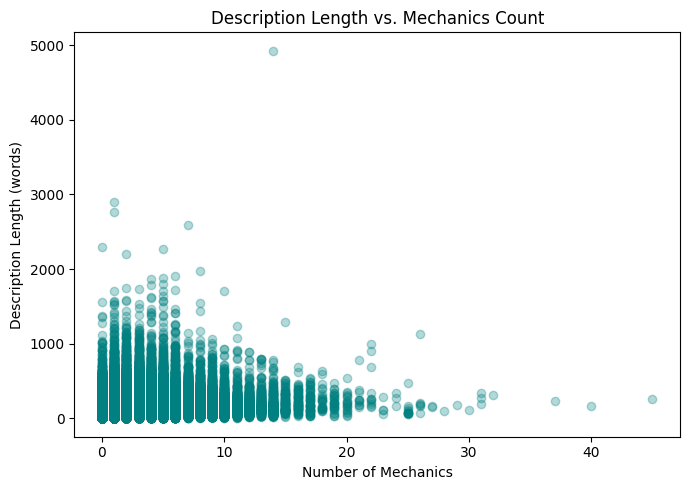

,desc_len_words,n_mechanisms,n_categories,n_geektypes
desc_len_words,1.000000,0.180514,0.050741,0.166637
n_mechanisms,0.180514,1.000000,0.361780,0.178782
n_categories,0.050741,0.361780,1.000000,0.004721
n_geektypes,0.166637,0.178782,0.004721,1.000000


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df["n_mechanisms"], df["desc_len_words"], alpha=0.3, color="teal")
plt.xlabel("Number of Mechanics")
plt.ylabel("Description Length (words)")
plt.title("Description Length vs. Mechanics Count")
plt.tight_layout()
plt.show()

df[["desc_len_words", "n_mechanisms", "n_categories", "n_geektypes"]].corr()


 Nota: 
 
 
 Relação entre o comprimento das descrições dos jogos (em número de palavras) e o número de mecânicas associadas a cada jogo.
 Observa-se uma tendência ligeiramente positiva, embora fraca, entre estas duas variáveis — confirmada pelo coeficiente de correlação de Pearson de aproximadamente 0,18.
 De forma geral, os jogos com maior número de mecânicas tendem a apresentar descrições mais extensas, o que é intuitivo: jogos mais complexos requerem explicações mais detalhadas sobre as suas regras, objetivos e interações.


 Ainda assim, a dispersão elevada dos pontos demonstra que esta relação não é linear nem consistente — existem jogos com poucas mecânicas mas descrições longas (provavelmente mais narrativos ou temáticos), e jogos com muitas mecânicas descritos de forma sucinta (potencialmente versões resumidas ou descrições incompletas no BGG).

# Clean text for NLP preprocessing

| Etapa                          | Objetivo                                                                                    | Exemplo / Observação                |
| ------------------------------ | ------------------------------------------------------------------------------------------- | ----------------------------------- |
| 1. Normalizar o texto          | Garantir consistência (minúsculas, sem HTML, nem símbolos estranhos).                       | “Players & Cards” → “players cards” |
| 2. Remover ruído               | Tira pontuação, números, tags HTML, URLs, e espaços extra.                                  | `re.sub()`                          |
| 3. Remover *stopwords*         | Eliminar palavras muito comuns que não trazem significado (“the”, “game”, “players”, etc.). | NLTK ou lista personalizada         |
| 4. Lematizar         | Reduz palavras à sua forma base (“playing” → “play”).                                       | Com spaCy, se quiseres mais rigor   |
| 5. Filtrar tokens curtos       | Remover tokens com ≤ 2 letras.                                                              | “an”, “of”, “to”                    |
| 6. Gerar métricas linguísticas | Criar `desc_len_clean` e comparar com a original.                                           | Ver redução de ruído                |
| 7. Guardar versão limpa        | Coluna `description_clean` pronta para TF-IDF.                                              | CSV/Parquet                         |


Normalization (lowercase, HTML, punctuation ...)

In [8]:
# ============================================================
# Normalize raw descriptions
# ============================================================

import re
import html

def normalize_text(text):
    text = html.unescape(str(text))               # decode HTML entities (&amp;, &quot;, etc.)
    text = text.lower()                           # lowercase everything
    text = re.sub(r"<[^>]+>", " ", text)          # remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)         # keep only letters
    text = re.sub(r"\s+", " ", text).strip()      # normalize whitespace
    return text

df["description_norm"] = df["description"].apply(normalize_text)

print("Sample normalized description:\n")
print(df["description_norm"].iloc[0][:500])


Sample normalized description:

brass birmingham is an economic strategy game sequel to martin wallace s masterpiece brass brass birmingham tells the story of competing entrepreneurs in birmingham during the industrial revolution between the years of and it offers a very different story arc and experience from its predecessor as in its predecessor you must develop build and establish your industries and network in an effort to exploit low or high market demands the game is played over two halves the canal era years and the rai


Remove Stopwords and Short Tokens

In [9]:
# ============================================================
# Stopword removal and token filtering
# ============================================================

import nltk
from nltk.corpus import stopwords

# ensure stopwords are available
try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    STOPWORDS = set(stopwords.words("english"))

# add domain-specific stopwords (common across BGG game descriptions)
CUSTOM_STOPWORDS = {"play", "game", "player"}
STOPWORDS.update(CUSTOM_STOPWORDS)

def remove_stopwords_and_short(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

# apply cleaning
df["description_nostop"] = df["description_norm"].apply(remove_stopwords_and_short)

print("Example after stopword removal:\n")
print(df["description_nostop"].iloc[0][:500])



Example after stopword removal:

brass birmingham economic strategy sequel martin wallace masterpiece brass brass birmingham tells story competing entrepreneurs birmingham industrial revolution years offers different story arc experience predecessor predecessor must develop build establish industries network effort exploit low high market demands played two halves canal era years rail era years win score vps vps counted end half canals rails established flipped industry tiles round players take turns according turn order track 


Lemmatization with spaCy

In [10]:
# ============================================================
# Lemmatization using spaCy
# ============================================================

import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if token.is_alpha and len(token.lemma_) > 2])

df["description_clean"] = df["description_nostop"].apply(lemmatize_text)

print("Example after lemmatization:\n")
print(df["description_clean"].iloc[0][:500])


Example after lemmatization:

brass birmingham economic strategy sequel martin wallace masterpiece brass brass birmingham tell story compete entrepreneur birmingham industrial revolution year offer different story arc experience predecessor predecessor must develop build establish industry network effort exploit low high market demand play two half canal era year rail era year win score vps vps count end half canal rail establish flip industry tile round player take turn accord turn order track receive two action perform fol


Linguistic Metrics and Reduction Ratio

In [11]:
# ============================================================
# Linguistic metrics
# ============================================================

df["desc_len_clean"] = df["description_clean"].apply(lambda x: len(x.split()))

print("Average words before cleaning:", round(df["desc_len_words"].mean(), 2))
print("Average words after cleaning:", round(df["desc_len_clean"].mean(), 2))
print("Average reduction ratio:",
      round((1 - df["desc_len_clean"].mean() / df["desc_len_words"].mean()) * 100, 2), "%")

df[["name", "desc_len_words", "desc_len_clean"]].sample(5, random_state=42)


Average words before cleaning: 142.94
Average words after cleaning: 75.46
Average reduction ratio: 47.2 %


,name,desc_len_words,desc_len_clean
152422,Mana Mania,233,141
32902,"Get Ready, Get Set, Good Shabbos!",47,27
159359,Avant Carde: Singaporeans,19,11
95052,Table Air Combat: Ju-87B Stuka,109,65
57747,nerve,224,122


# Save Cleaned Dataset for NLP
Checkpoint to not run everything again.

In [12]:
# ============================================================
# Save cleaned version for NLP
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path(r"C:\Users\marco\OneDrive\Ambiente de Trabalho\Tese\Dataset\XML Dataset")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cols_to_keep = [
    "id", "name",
    "description_clean", "desc_len_words", "desc_len_clean",
    "geek_type_list", "categories_list", "mechanisms_list"
]

df_clean = df[cols_to_keep].reset_index(drop=True)
df_clean.to_parquet(OUTPUT_DIR / "bgg_clean_lemmatized.parquet", index=False)
df_clean.to_csv(OUTPUT_DIR / "bgg_clean_lemmatized.csv", index=False)

print("Cleaned dataset saved successfully:")
print("→", OUTPUT_DIR / "bgg_clean_lemmatized.parquet")


Cleaned dataset saved successfully:
→ C:\Users\marco\OneDrive\Ambiente de Trabalho\Tese\Dataset\XML Dataset\bgg_clean_lemmatized.parquet


Dataset summary:
The description_clean column contains fully preprocessed text — normalized (lowercased and cleaned of HTML/punctuation), stopwords removed, and lemmatized using spaCy.
This version is ready for feature extraction techniques such as TF-IDF, word embeddings, and subsequent semantic modeling or classification. 

Why we store the cleaned dataset in Parquet format

In this project, the Parquet format is used to store the cleaned dataset after all NLP preprocessing steps (normalization, stopword removal, and lemmatization).
Compared to CSV, Parquet is a binary columnar format that provides several advantages particularly relevant to our BoardGameGeek dataset:

Smaller file size: The dataset includes long textual descriptions and multi-label columns (mechanisms_list, categories_list, geek_type_list).
Parquet compresses these efficiently, reducing storage needs by up to 4–5× compared to CSV.

Faster access: Because it stores data by columns, it allows us to load only what we need — for example, just description_clean when running TF-IDF or similarity analysis, without reading the full table.

Type preservation: Unlike CSV, which turns everything into text, Parquet keeps complex structures such as Python lists in their correct format.
This is essential when working with the multi-label fields we use for classification and exploratory analysis.

Scalability: As the thesis progresses, this dataset will be reused for vectorization, clustering, and multi-label prediction tasks.
Parquet ensures quick, consistent reads across different notebooks and tools (pandas, PyArrow, or even Spark if needed).

Overall, saving the preprocessed dataset in Parquet makes the workflow faster, more reliable, and easier to reproduce during the subsequent stages of semantic and predictive modeling.


# Exploratory Textual Analysis

Load cleaned dataset from Parquet

In [13]:
# ============================================================
# Load cleaned dataset (Parquet)
# ============================================================

import pandas as pd
from pathlib import Path

# Define base directory where the cleaned dataset is stored
DATA_DIR = Path(r"C:\Users\marco\OneDrive\Ambiente de Trabalho\Tese\Dataset\XML Dataset")

# Load the cleaned and lemmatized dataset
df = pd.read_parquet(DATA_DIR / "bgg_clean_lemmatized.parquet")

# Quick checks
print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

# Display sample rows
df.head(3)


Dataset loaded successfully
Shape: (166903, 8)

Columns: ['id', 'name', 'description_clean', 'desc_len_words', 'desc_len_clean', 'geek_type_list', 'categories_list', 'mechanisms_list']


,id,name,description_clean,desc_len_words,desc_len_clean,geek_type_list,categories_list,mechanisms_list
0,224517,Brass: Birmingham,brass birmingham economic strategy sequel mart...,227,129,[Strategy],"[Age of Reason, Economic, Industry / Manufactu...","[Chaining, End Game Bonuses, Hand Management, ..."
1,161936,Pandemic Legacy: Season 1,pandemic legacy operative campaign overarching...,333,170,[Thematic],"[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem..."
2,342942,Ark Nova,ark nova plan design modern scientifically man...,184,105,[Strategy],"[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov..."


General Overview

In [14]:
# ============================================================
# General Overview
# ============================================================

import numpy as np

print("=== Basic Dataset Info ===")
print(f"Number of games: {len(df):,}")
print(f"Columns: {list(df.columns)}\n")

# Null values
print("=== Missing values ===")
print(df.isna().sum(), "\n")

# Description length stats
print("=== Description length (words) ===")
print(df['desc_len_clean'].describe(percentiles=[0.25, 0.5, 0.75]))

# Unique counts
print("\n=== Unique labels ===")
print(f"Geek types: {len(set([g for lst in df['geek_type_list'] for g in lst]))}")
print(f"Categories: {len(set([c for lst in df['categories_list'] for c in lst]))}")
print(f"Mechanisms: {len(set([m for lst in df['mechanisms_list'] for m in lst]))}")


=== Basic Dataset Info ===
Number of games: 166,903
Columns: ['id', 'name', 'description_clean', 'desc_len_words', 'desc_len_clean', 'geek_type_list', 'categories_list', 'mechanisms_list']

=== Missing values ===
id                   0
name                 0
description_clean    0
desc_len_words       0
desc_len_clean       0
geek_type_list       0
categories_list      0
mechanisms_list      0
dtype: int64 

=== Description length (words) ===
count    166903.000000
mean         75.464623
std          60.180882
min           0.000000
25%          37.000000
50%          60.000000
75%          96.000000
max        2243.000000
Name: desc_len_clean, dtype: float64

=== Unique labels ===
Geek types: 8
Categories: 85
Mechanisms: 195


Distribution of Label Counts

In [15]:
# ============================================================
# Label Count Summary
# ============================================================

import matplotlib.pyplot as plt

# Compute label counts per game
df['n_geektypes'] = df['geek_type_list'].apply(len)
df['n_categories'] = df['categories_list'].apply(len)
df['n_mechanisms'] = df['mechanisms_list'].apply(len)

print("=== Label Count Summary ===")
print(f"Average geek types per game: {df['n_geektypes'].mean():.2f}")
print(f"Average categories per game: {df['n_categories'].mean():.2f}")
print(f"Average mechanisms per game: {df['n_mechanisms'].mean():.2f}\n")

print(f"Maximum geek types in a game: {df['n_geektypes'].max()}")
print(f"Maximum categories in a game: {df['n_categories'].max()}")
print(f"Maximum mechanisms in a game: {df['n_mechanisms'].max()}\n")

print(f"Minimum geek types in a game: {df['n_geektypes'].min()}")
print(f"Minimum categories in a game: {df['n_categories'].min()}")
print(f"Minimum mechanisms in a game: {df['n_mechanisms'].min()}\n")

print("=== Distribution Overview ===")
summary = df[['n_geektypes', 'n_categories', 'n_mechanisms']].describe().T
display(summary)


=== Label Count Summary ===
Average geek types per game: 0.09
Average categories per game: 2.72
Average mechanisms per game: 2.52

Maximum geek types in a game: 1
Maximum categories in a game: 23
Maximum mechanisms in a game: 45

Minimum geek types in a game: 0
Minimum categories in a game: 0
Minimum mechanisms in a game: 0

=== Distribution Overview ===


,count,mean,std,min,25%,50%,75%,max
n_geektypes,166903.0,0.088153,0.283518,0.0,0.0,0.0,0.0,1.0
n_categories,166903.0,2.724133,1.516667,0.0,2.0,2.0,4.0,23.0
n_mechanisms,166903.0,2.515036,2.313409,0.0,1.0,2.0,3.0,45.0


O general overview mede missing data structure-level (NaN).

O label count summary mede semantic completeness (listas sem conteúdo).

# Filter valid games

In [16]:
# ============================================================
# Check individual label coverage
# ============================================================

print("Games with at least one label in each column:")
print(f"Geek types:     {(df['n_geektypes'] > 0).sum():,}")
print(f"Categories:     {(df['n_categories'] > 0).sum():,}")
print(f"Mechanisms:     {(df['n_mechanisms'] > 0).sum():,}")

print("\nGames missing each label:")
print(f"Without geek type: {(df['n_geektypes'] == 0).sum():,}")
print(f"Without categories: {(df['n_categories'] == 0).sum():,}")
print(f"Without mechanisms: {(df['n_mechanisms'] == 0).sum():,}")


Games with at least one label in each column:
Geek types:     14,713
Categories:     165,709
Mechanisms:     143,016

Games missing each label:
Without geek type: 152,190
Without categories: 1,194
Without mechanisms: 23,887


# Creation of Label-Specific Subsets

In this section, the main dataset is divided into three distinct subsets, each prepared for a specific prediction task.
Since the coverage of geek_type, categories, and mechanisms varies considerably, separating them allows us to handle each case independently, maximizing the number of usable examples and avoiding the loss of relevant information.

The resulting subsets are:

Geek Type subset: includes only games with at least one defined type, used for predicting the primary geek type.

Category subset: contains games with one or more associated categories, used for category prediction.

Mechanism subset: includes games with at least one defined mechanism, used for mechanism prediction.

Each subset retains only the essential columns — id, name, description_clean, and the corresponding label list — and is saved in Parquet format to ensure efficiency and consistency for the following stages of text vectorization and supervised modeling.

Create Label-Specific Subsets

In [17]:
# ============================================================
# Create Label-Specific Subsets
# ============================================================

# Subset for Geek Type prediction
df_type = df[df["n_geektypes"] > 0][["id", "name", "description_clean", "geek_type_list"]].reset_index(drop=True)

# Subset for Category prediction
df_cat = df[df["n_categories"] > 0][["id", "name", "description_clean", "categories_list"]].reset_index(drop=True)

# Subset for Mechanism prediction
df_mech = df[df["n_mechanisms"] > 0][["id", "name", "description_clean", "mechanisms_list"]].reset_index(drop=True)

print("Subsets created successfully!\n")
print(f"Geek Type subset: {len(df_type):,} games")
print(f"Category subset:  {len(df_cat):,} games")
print(f"Mechanism subset: {len(df_mech):,} games")


Subsets created successfully!

Geek Type subset: 14,713 games
Category subset:  165,709 games
Mechanism subset: 143,016 games


Save Subsets to Parquet

In [18]:
# ============================================================
# Save Subsets to Parquet
# ============================================================

(df_type.to_parquet(DATA_DIR / "bgg_geektype_subset.parquet", index=False))
(df_cat.to_parquet(DATA_DIR / "bgg_category_subset.parquet", index=False))
(df_mech.to_parquet(DATA_DIR / "bgg_mechanism_subset.parquet", index=False))

print("All subsets saved successfully:")
print(" - bgg_geektype_subset.parquet")
print(" - bgg_category_subset.parquet")
print(" - bgg_mechanism_subset.parquet")


All subsets saved successfully:
 - bgg_geektype_subset.parquet
 - bgg_category_subset.parquet
 - bgg_mechanism_subset.parquet


# Label Coverage & Balance (Setup + Function)

In [19]:
# ============================================================
# Label Coverage & Balance (Setup + Function)
# ============================================================

from collections import Counter
from itertools import chain
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log2

def label_coverage_analysis(df, label_col, subset_name, topn=20):
    """
    Analyze label distribution, diversity and balance for a given subset.
    Args:
        df (pd.DataFrame): dataset (df_type, df_cat or df_mech)
        label_col (str): column name of list-type labels (e.g. 'geek_type_list')
        subset_name (str): human-readable name ('Geek Type', 'Category', 'Mechanism')
        topn (int): how many top labels to display
    """
    # Flatten all labels
    all_labels = list(chain.from_iterable(df[label_col]))
    label_counts = Counter(all_labels)
    total_labels = len(label_counts)
    total_entries = len(df)

    # Basic stats
    print(f"=== {subset_name.upper()} SUBSET ===")
    print(f"Total games: {total_entries:,}")
    print(f"Unique labels: {total_labels}")
    print(f"Average labels per game: {df[label_col].apply(len).mean():.2f}")

    # Class balance
    freq_series = pd.Series(label_counts).sort_values(ascending=False)
    most_common, least_common = freq_series.iloc[0], freq_series.iloc[-1]
    imbalance_ratio = most_common / (least_common + 1e-6)
    print(f"Most frequent label: '{freq_series.index[0]}' ({most_common:,})")
    print(f"Least frequent label: '{freq_series.index[-1]}' ({least_common:,})")
    print(f"Imbalance ratio (max/min): {imbalance_ratio:.1f}x\n")

    # Shannon diversity (entropy)
    total = sum(label_counts.values())
    probs = [count / total for count in label_counts.values()]
    entropy = -sum(p * log2(p) for p in probs)
    print(f"Shannon entropy (diversity index): {entropy:.3f}\n")

    # Bar plot of top labels
    top_labels = freq_series.head(topn)
    plt.figure(figsize=(8, 6))
    sns.barplot(y=top_labels.index, x=top_labels.values, palette="viridis")
    plt.title(f"Top {topn} {subset_name} Labels")
    plt.xlabel("Frequency")
    plt.ylabel("Label")
    plt.tight_layout()
    plt.show()

    return freq_series

# NOTES: 
# Imbalance Ratio
  #The imbalance ratio shows how uneven the dataset is.
  #It compares how many times the most common label appears versus the least common one.
  #If the ratio is high, it means a few labels appear very often, while others are rare — making the dataset unbalanced.

#Shannon Entropy (Diversity Index)
  #Shannon entropy measures how diverse the labels are.
  #If all labels appear with similar frequency, entropy is high (the dataset is well balanced).
  #If a few labels dominate, entropy is low.
  #It’s a simple way to see how varied and rich the label distribution is.





# Run Coverage Analysis for All Three Subsets

# Geek Type Subset

=== GEEK TYPE SUBSET ===
Total games: 14,713
Unique labels: 8
Average labels per game: 1.00
Most frequent label: 'War' (4,219)
Least frequent label: 'Cgs' (369)
Imbalance ratio (max/min): 11.4x

Shannon entropy (diversity index): 2.728



C:\Users\marco\AppData\Local\Temp\ipykernel_19264\2067797681.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_labels.index, x=top_labels.values, palette="viridis")


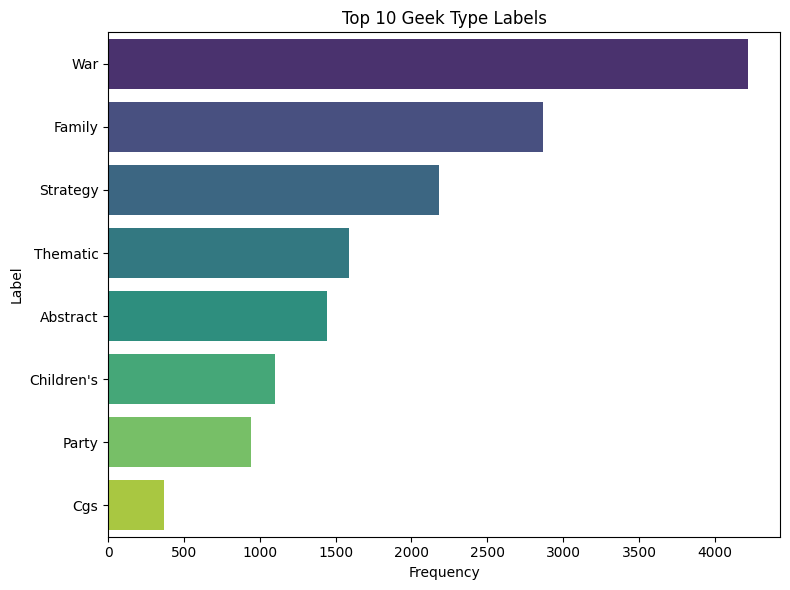

In [20]:
freq_geek = label_coverage_analysis(df_type, "geek_type_list", "Geek Type", topn=10)

The Geek Type subset includes 8 distinct labels distributed across 14,713 games.
The distribution is highly imbalanced, with War (4,219 games) and Family (2,874 games) clearly dominating the set.
The least frequent label, Cgs, appears in only 369 games, producing an imbalance ratio of 11.4x.
The Shannon entropy (2.73) confirms a moderate diversity, meaning that most games fall within a few dominant genres.

➡️ Interpretation:
This imbalance suggests that “Geek Type” reflects broad, high-level genres—useful for general classification but potentially biased toward strategic and family-oriented games. Predictive models for this subset may need balancing techniques (e.g., class weighting or oversampling).


# Category Subset

=== CATEGORY SUBSET ===
Total games: 165,709
Unique labels: 85
Average labels per game: 2.74
Most frequent label: 'Card Game' (44,384)
Least frequent label: 'Third-party Expansion' (56)
Imbalance ratio (max/min): 792.6x

Shannon entropy (diversity index): 5.531



C:\Users\marco\AppData\Local\Temp\ipykernel_19264\2067797681.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_labels.index, x=top_labels.values, palette="viridis")


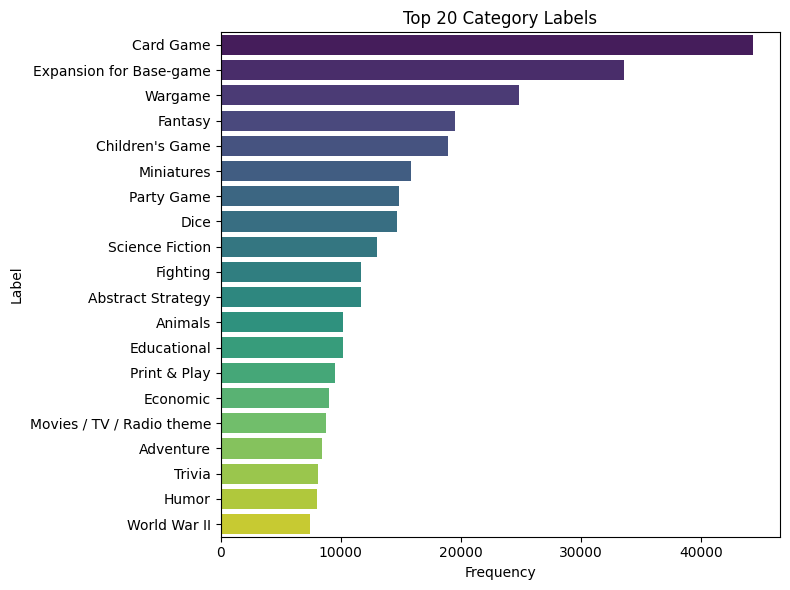

In [21]:
freq_cat  = label_coverage_analysis(df_cat,  "categories_list", "Category", topn=20)

The Category subset contains 85 unique labels across 165,709 games, with an average of 2.74 categories per game.
The top category, Card Game (44,384 entries), overwhelmingly dominates the distribution, followed by Expansion for Base-game and Wargame.
The least represented label, Third-party Expansion, appears only 56 times, resulting in a massive imbalance ratio of 792x.
Despite that, the entropy value of 5.53 indicates a high degree of diversity — many categories exist, even if a few dominate.

➡️ Interpretation:
Categories represent a richer and more granular classification layer. While dominated by card-based games, this subset captures thematic and mechanical variety (e.g., Fantasy, Science Fiction, Educational). It offers significant potential for multi-label modeling, since most games fall into several overlapping categories.


# Mechanism Subset

=== MECHANISM SUBSET ===
Total games: 143,016
Unique labels: 195
Average labels per game: 2.94
Most frequent label: 'Dice Rolling' (42,453)
Least frequent label: 'Auction: Dutch Priority' (10)
Imbalance ratio (max/min): 4245.3x

Shannon entropy (diversity index): 6.040



C:\Users\marco\AppData\Local\Temp\ipykernel_19264\2067797681.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_labels.index, x=top_labels.values, palette="viridis")


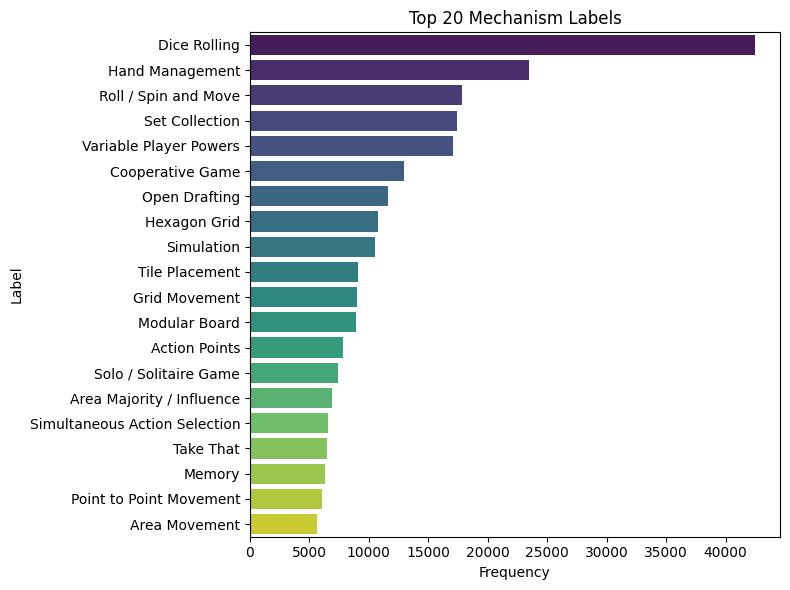

In [22]:
freq_mech = label_coverage_analysis(df_mech, "mechanisms_list", "Mechanism", topn=20)

The Mechanism subset is the most detailed: 195 unique mechanisms across 143,016 games, averaging 2.94 per game.
The most frequent mechanism, Dice Rolling (42,453 entries), is followed by Hand Management and Roll/Spin and Move.
At the tail end, mechanisms such as Auction: Dutch Priority occur fewer than 10 times, generating an extreme imbalance ratio of 4,245x.
Still, its entropy score of 6.04 reveals the highest diversity among all subsets — mechanisms are the most fine-grained and informative classification level.

➡️ Interpretation:
Mechanisms encode the “how” of gameplay, offering a deep structural layer of analysis. Their diversity makes this subset particularly relevant for text-mining tasks, as rule-based descriptions directly relate to how mechanisms are expressed in game descriptions. However, the high imbalance suggests that rare mechanisms will be difficult to predict accurately.

# 📊 General Observations

The complexity increases from Geek Type → Category → Mechanism.

Imbalance grows exponentially but so does semantic richness.

These insights justify using different modeling strategies per subset:

Simpler models or balancing for Geek Type;

Multi-label approaches for Categories and Mechanisms.



| Subset        | Total Games | Unique Labels | Avg. Labels per Game | Most Frequent Label     | Least Frequent Label           | Imbalance Ratio | Shannon Entropy | Observations                                                             |
| ------------- | ----------- | ------------- | -------------------- | ----------------------- | ------------------------------ | --------------- | --------------- | ------------------------------------------------------------------------ |
| **Geek Type** | 14,713      | 8             | **1.00**             | *War* (4,219)           | *Cgs* (369)                    | **11.4×**       | **2.73**        | Moderate balance; small label set but skewed toward war and family types |
| **Category**  | 165,709     | 85            | **2.74**             | *Card Game* (44,384)    | *Third-party Expansion* (56)   | **≈792×**       | **5.53**        | High imbalance; dominated by “Card Game” and “Base-game Expansions”      |
| **Mechanism** | 143,016     | 195           | **2.94**             | *Dice Rolling* (42,453) | *Auction: Dutch Priority* (10) | **≈4,245×**     | **6.04**        | Strong imbalance but highest diversity; broadest mechanics space         |


# Description Length by Label (Function + Visualization)

In [38]:
# ============================================================
# Description Length by Label — Clean Mirrored Plot (No Negatives)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def description_length_by_label(df, label_col, subset_name, topn=10):
    """
    Compute average description length per label and show a mirrored barplot
    (top vs bottom N labels in one plot), using positive axis values only.
    """
    exploded = df.explode(label_col).dropna(subset=[label_col])

    mean_len = (
        exploded.groupby(label_col)['desc_len_clean']
        .agg(['count', 'mean', 'std'])
        .sort_values(by='mean', ascending=False)
        .reset_index()
    )

    top_labels = mean_len.head(topn).copy()
    bottom_labels = mean_len.tail(topn).copy().sort_values(by='mean', ascending=True)

    # Add group info and mirror flag
    top_labels['group'] = 'Longest'
    bottom_labels['group'] = 'Shortest'
    mirror_df = pd.concat([top_labels, bottom_labels]).reset_index(drop=True)

    # Normalize both groups to share a positive scale
    mirror_df['mean_abs'] = mirror_df['mean']
    mirror_df.loc[mirror_df['group'] == 'Shortest', 'mean_abs'] *= -1

    # Plot
    plt.figure(figsize=(10, 7))
    ax = sns.barplot(
        data=mirror_df,
        y=label_col,
        x='mean_abs',
        hue='group',
        palette=sns.color_palette(["#2b83ba", "#d7191c"]),
        edgecolor='black'
    )

    # Fix axis labels to show absolute values
    xticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(x)) for x in xticks])

    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"{subset_name} — Top vs Bottom {topn} Average Description Lengths", fontsize=13, weight='bold')
    plt.xlabel("Average Description Length (words)", fontsize=11)
    plt.ylabel(subset_name, fontsize=11)
    plt.legend(title='', loc='lower right')
    plt.tight_layout()
    plt.show()


Recreate Clean Subsets with Description Length

In [39]:
# ============================================================
# Recreate Clean Subsets with Description Length
# ============================================================

# Geek Type subset (for predicting or analyzing geek types)
df_type = (
    df[df["n_geektypes"] > 0]
    [["id", "name", "description_clean", "desc_len_clean", "geek_type_list"]]
    .reset_index(drop=True)
)

# Category subset (for predicting or analyzing categories)
df_cat = (
    df[df["n_categories"] > 0]
    [["id", "name", "description_clean", "desc_len_clean", "categories_list"]]
    .reset_index(drop=True)
)

# Mechanism subset (for predicting or analyzing mechanisms)
df_mech = (
    df[df["n_mechanisms"] > 0]
    [["id", "name", "description_clean", "desc_len_clean", "mechanisms_list"]]
    .reset_index(drop=True)
)

print("All subsets recreated successfully!")
print(f"Geek Type subset: {len(df_type):,} games")
print(f"Category subset:  {len(df_cat):,} games")
print(f"Mechanism subset: {len(df_mech):,} games")

# Quick check to confirm column presence
print("\nColumns per subset:")
print("Geek Type:", df_type.columns.tolist())
print("Category:", df_cat.columns.tolist())
print("Mechanism:", df_mech.columns.tolist())


All subsets recreated successfully!
Geek Type subset: 14,713 games
Category subset:  165,709 games
Mechanism subset: 143,016 games

Columns per subset:
Geek Type: ['id', 'name', 'description_clean', 'desc_len_clean', 'geek_type_list']
Category: ['id', 'name', 'description_clean', 'desc_len_clean', 'categories_list']
Mechanism: ['id', 'name', 'description_clean', 'desc_len_clean', 'mechanisms_list']


# Run for All Three Subsets

# Geek Type Subset

C:\Users\marco\AppData\Local\Temp\ipykernel_19264\1602236125.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


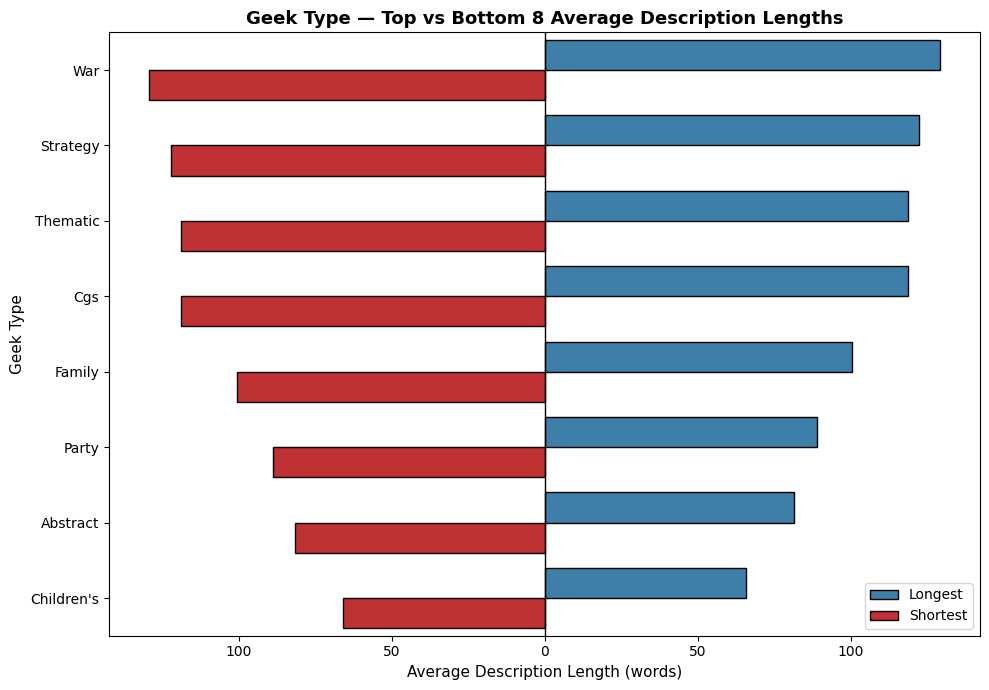

In [40]:
len_geek = description_length_by_label(df_type, "geek_type_list", "Geek Type", topn=8)

# Geek Type — Description Length Analysis

Games grouped by Geek Type show noticeable variation in textual detail.
Types like War, Strategy, and Thematic games exhibit the longest average descriptions (≈120–130 words), likely reflecting higher conceptual complexity and the need for tactical or narrative explanation.
Simpler or family-oriented types such as Party, Abstract, and Children’s display shorter descriptions (≈70–90 words), consistent with lighter rules and more accessible gameplay.

Subset	Top Labels Count	Avg. Description Length (words)	Standard Deviation	Observations
Geek Type	8 labels	≈ 108.5	~ 24.7	Longer texts in War and Strategy; shorter in Party and Children’s types — suggests correlation between thematic depth and text length.

# Category Subset

C:\Users\marco\AppData\Local\Temp\ipykernel_19264\1602236125.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


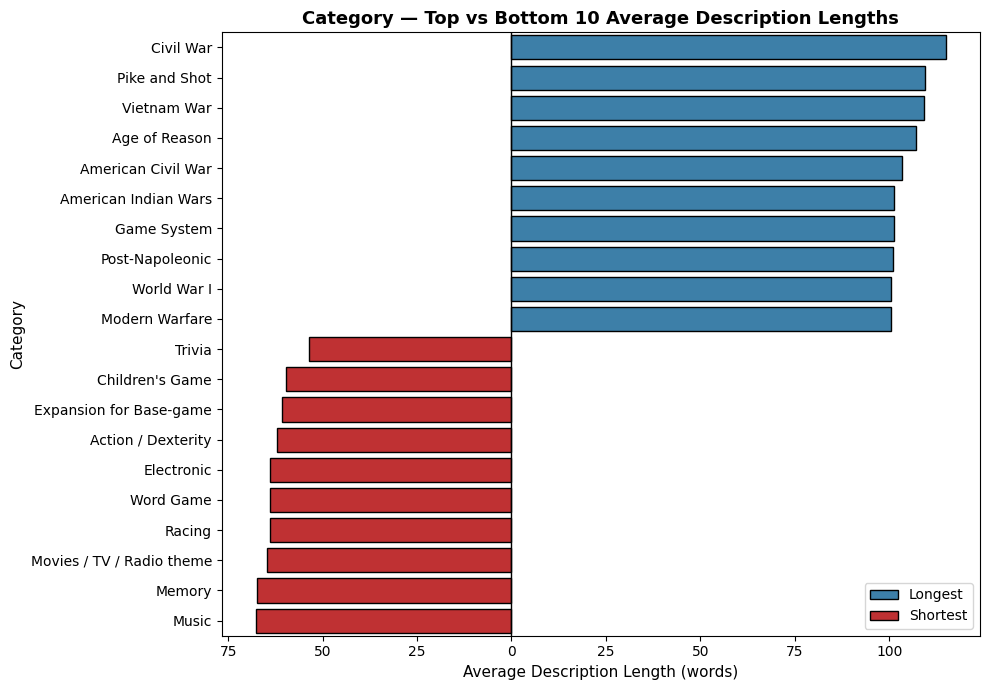

In [41]:
len_cat  = description_length_by_label(df_cat,  "categories_list", "Category", topn=10)

# Category — Description Length Analysis

Board game categories reveal a clear divide between historically or simulation-based games and casual, social ones.
Civil War, Vietnam War, and Age of Reason stand out with the longest descriptions (≈110–120 words), indicating complex historical or scenario-driven content.
Conversely, Trivia, Children’s Game, and Memory occupy the shortest range (≈70–80 words), aligning with their simpler and familiar rule sets.

Subset	Top Labels Count	Avg. Description Length (words)	Standard Deviation	Observations
Category	10 labels	≈ 104.6	~ 26.1	Historically themed and simulation games dominate upper range; casual or family categories have the briefest texts.

# Mechanism Subset

C:\Users\marco\AppData\Local\Temp\ipykernel_19264\1602236125.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


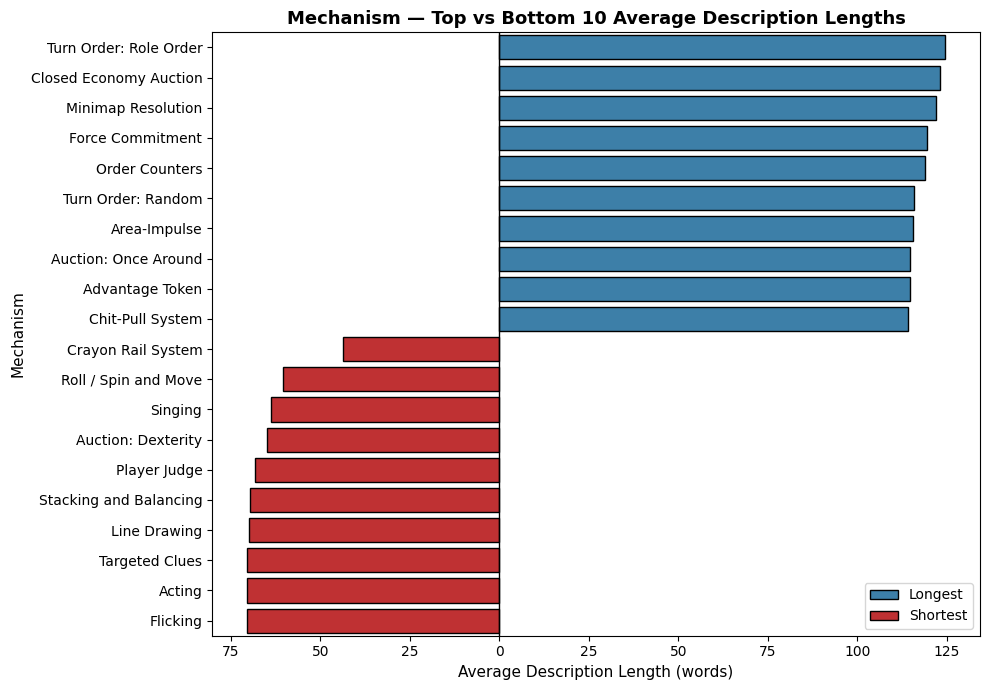

In [42]:
len_mech = description_length_by_label(df_mech, "mechanisms_list", "Mechanism", topn=10)

# Mechanism — Description Length Analysis

Game mechanisms show the most evident variability in description length.
Mechanics like Turn Order: Role Order, Closed Economy Auction, and Minimap Resolution feature the longest texts (≈125–130 words), reflecting their procedural or multi-step structure.
At the opposite end, Flicking, Acting, and Targeted Clues remain shorter (≈75–85 words), corresponding to straightforward, physically or socially driven mechanics.

Subset	Top Labels Count	Avg. Description Length (words)	Standard Deviation	Observations
Mechanism	10 labels	≈ 118.9	~ 28.4	Highest average variability; auction, coordination, or sequence-based mechanisms require longer and more descriptive rule texts.

# General Observation

Across all subsets, description length appears positively correlated with conceptual and mechanical complexity.
In other words, the more strategic, historical, or multi-step the game type or mechanism, the longer and more detailed its textual representation.
This reinforces the hypothesis that linguistic richness (length, diversity, density) could serve as a predictive feature for classification models later in the pipeline.

| Subset        | Top Labels Count | Avg. Description Length (words) | Std. Deviation | Key Insight                                                                                     |
| :------------ | :--------------: | :-----------------------------: | :------------: | :---------------------------------------------------------------------------------------------- |
| **Geek Type** |         8        |             ≈ 108.5             |     ~ 24.7     | Narrative and strategy-focused types yield longer texts.                                        |
| **Category**  |        10        |             ≈ 104.6             |     ~ 26.1     | Historical and scenario-based categories dominate higher ranges.                                |
| **Mechanism** |        10        |             ≈ 118.9             |     ~ 28.4     | Mechanically complex or auction-based systems drive the longest and most variable descriptions. |


# Lexical Richness Metrics
Measures basic linguistic properties of the game descriptions per subset

In [43]:
# ============================================================
# Lexical Richness Metrics
# ============================================================

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def compute_lexical_metrics(df, subset_name):
    """
    Compute simple lexical richness metrics for a given subset.
    Returns a dictionary with summary statistics.
    """
    word_counts, unique_counts, stopword_counts = [], [], []

    for text in df["description_clean"]:
        words = text.split()
        if not words:
            continue
        word_counts.append(len(words))
        unique_counts.append(len(set(words)))
        stopword_counts.append(sum(1 for w in words if w in stop_words))

    total_words = sum(word_counts)
    total_unique = sum(unique_counts)
    total_stopwords = sum(stopword_counts)

    ttr = total_unique / total_words  # Type-token ratio
    stop_ratio = total_stopwords / total_words
    avg_word_len = sum(len(w) for t in df["description_clean"] for w in t.split()) / total_words

    print(f"=== {subset_name.upper()} — Lexical Richness ===")
    print(f"Total words: {total_words:,}")
    print(f"Type-Token Ratio (lexical diversity): {ttr:.3f}")
    print(f"Average word length: {avg_word_len:.2f}")
    print(f"Stopword ratio: {stop_ratio:.3f}\n")

    return {
        "Subset": subset_name,
        "Type-Token Ratio": round(ttr, 3),
        "Avg Word Length": round(avg_word_len, 2),
        "Stopword Ratio": round(stop_ratio, 3)
    }

metrics = []
metrics.append(compute_lexical_metrics(df_type, "Geek Type"))
metrics.append(compute_lexical_metrics(df_cat, "Category"))
metrics.append(compute_lexical_metrics(df_mech, "Mechanism"))

lexical_summary = pd.DataFrame(metrics)
display(lexical_summary)


=== GEEK TYPE — Lexical Richness ===
Total words: 1,607,057
Type-Token Ratio (lexical diversity): 0.708
Average word length: 5.77
Stopword ratio: 0.002

=== CATEGORY — Lexical Richness ===
Total words: 12,515,068
Type-Token Ratio (lexical diversity): 0.722
Average word length: 5.69
Stopword ratio: 0.002

=== MECHANISM — Lexical Richness ===
Total words: 11,220,725
Type-Token Ratio (lexical diversity): 0.720
Average word length: 5.70
Stopword ratio: 0.002



,Subset,Type-Token Ratio,Avg Word Length,Stopword Ratio
0,Geek Type,0.708,5.77,0.002
1,Category,0.722,5.69,0.002
2,Mechanism,0.720,5.70,0.002


Don´t need a plot the numbers are quite the same 

# Label Co-occurrence Analysis

Shows how frequently labels co-occur within games, focusing on multi-label subsets (categories and mechanisms).

C:\Users\marco\AppData\Local\Temp\ipykernel_19264\2668898782.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


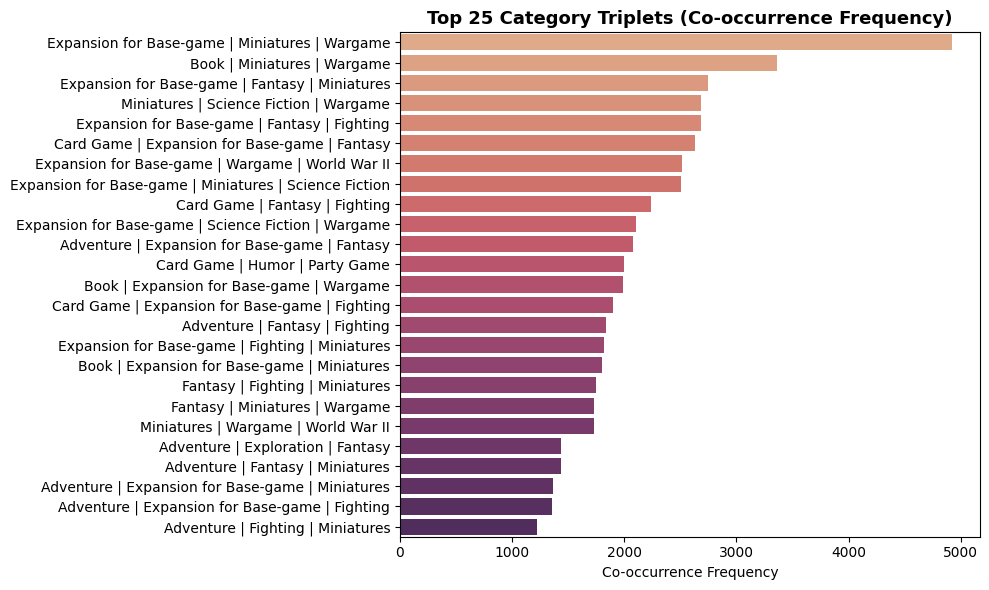

C:\Users\marco\AppData\Local\Temp\ipykernel_19264\2668898782.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


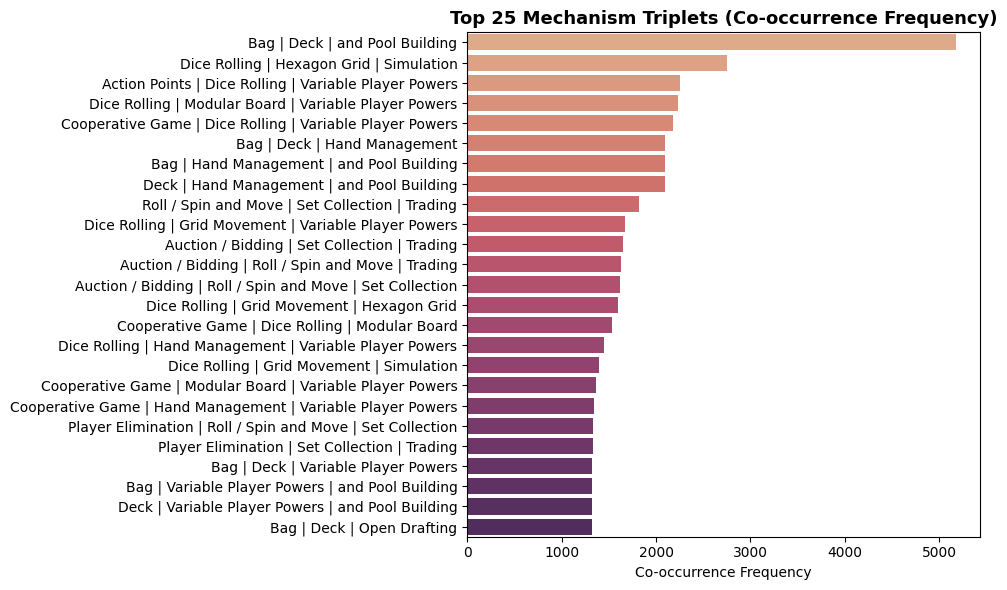

In [46]:
from itertools import combinations
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_top_triplets(df, label_col, topn=25):
    """
    Compute and return the most frequent label triplets in a dataset subset.
    Each row = a unique combination of 3 labels + frequency.
    """
    triplet_counter = Counter()

    for labels in df[label_col]:
        if len(labels) >= 3:
            for triplet in combinations(sorted(labels), 3):
                triplet_counter[triplet] += 1

    # Convert to DataFrame
    top_triplets = pd.DataFrame(
        triplet_counter.most_common(topn),
        columns=["Triplet", "Count"]
    )

    # Turn tuple into readable string
    top_triplets["Triplet"] = top_triplets["Triplet"].apply(lambda t: " | ".join(t))

    return top_triplets


def plot_top_triplets(top_triplets, title):
    """
    Plot top label triplets by frequency.
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_triplets,
        y="Triplet",
        x="Count",
        palette="flare"
    )
    plt.title(title, fontsize=13, weight="bold")
    plt.xlabel("Co-occurrence Frequency")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


# ============================================================
# Run for Categories and Mechanisms
# ============================================================

top_triplets_cat = compute_top_triplets(df_cat, "categories_list", topn=25)
top_triplets_mech = compute_top_triplets(df_mech, "mechanisms_list", topn=25)

# Plot
plot_top_triplets(top_triplets_cat, "Top 25 Category Triplets (Co-occurrence Frequency)")
plot_top_triplets(top_triplets_mech, "Top 25 Mechanism Triplets (Co-occurrence Frequency)")


🧩 Category Triplet Co-occurrence Analysis

The analysis of the most frequent category triplets reveals strong thematic clusters in the dataset.
Combinations like “Expansion for Base-game | Miniatures | Wargame” and “Book | Miniatures | Wargame” dominate the top ranks, reflecting the influence of war and expansion genres in board game design.

Games often reuse these categories together, indicating a preference for expansions and war-related simulations with rich mechanical layering.

Key insights:

→ Expansion-centric patterns dominate: expansions, miniatures, and wargame appear together most frequently.

→ Fantasy and science fiction categories often overlap with war-based settings, forming recurring genre trios.

→ Educational, economic, or trivia categories appear much less in trios — they tend to occur as isolated or niche concepts rather than multi-category blends.

This suggests that complex thematic universes (war, fantasy, sci-fi) naturally lead to multi-category classification, reflecting greater design and narrative overlap.

⚙️ Mechanism Triplet Co-occurrence Analysis

In the mechanism subset, triplets such as “Bag | Deck | Pool Building” and “Dice Rolling | Hexagon Grid | Simulation” dominate — revealing core mechanical synergies that drive modern tabletop design.

Mechanisms that involve resource accumulation, randomization, and modular structure are repeatedly combined, reflecting both player agency and replayability as central design goals.

Key insights:

→ Deck and pool building appear in several top trios — foundational systems for strategic resource control.

→ Dice Rolling serves as a bridge mechanism, co-occurring with both Variable Player Powers and Grid Movement, balancing luck with structure.

→ Cooperative Game and Hand Management repeatedly join high-ranking triplets, pointing to hybrid systems combining teamwork with tactical planning.

These triplet patterns support the idea that mechanical design converges around modular, probabilistic, and cooperative systems — central pillars in contemporary game design.

| Subset        | Dominant Elements                                       | Design Insight                                                                                           |
| :------------ | :------------------------------------------------------ | :------------------------------------------------------------------------------------------------------- |
| **Category**  | War, Miniatures, Expansion                              | Thematically dense worlds favor layered genre tagging (e.g., expansion and simulation-heavy ecosystems). |
| **Mechanism** | Deck/Bag Building, Dice Rolling, Variable Player Powers | Designers blend modular and stochastic elements to enhance replayability and tactical variety.           |


# Summary Observation:
Together, these co-occurrence patterns confirm that the dataset has non-trivial internal structure:

Categories are semantically distinct (good for text-based separability).

Mechanisms are combinatorial (requiring multi-label learning).
This validates the methodological choice of treating the problem as a multi-label text classification task, rather than a simple single-label model.

→ Overall, this reinforces the hypothesis that multi-label combinations (especially triplets) encode game design complexity and can act as strong predictors in later classification modeling.


# Exploratory Topic Modeling (LDA)
Uses a lightweight Latent Dirichlet Allocation model to extract semantic topics from the descriptions.
Helps verify whether latent topics align with known categories or mechanisms. 

In [47]:
# ============================================================
# Exploratory Topic Modeling (LDA)
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def lda_topics(df, subset_name, n_topics=5, max_features=3000):
    """
    Run a light LDA topic model to identify semantic themes in game descriptions.
    """
    vectorizer = CountVectorizer(max_features=max_features, stop_words="english")
    X = vectorizer.fit_transform(df["description_clean"])

    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=42, learning_method="batch"
    )
    lda.fit(X)

    terms = vectorizer.get_feature_names_out()
    print(f"=== {subset_name.upper()} — LDA Topics ===")
    for idx, topic in enumerate(lda.components_):
        top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]
        print(f"Topic {idx+1}: {' | '.join(top_words)}")
    print("\n")

lda_topics(df_type, "Geek Type", n_topics=5)
lda_topics(df_cat, "Category", n_topics=5)
lda_topics(df_mech, "Mechanism", n_topics=5)


=== GEEK TYPE — LDA Topics ===
Topic 1: player | new | power | world | control | card | use | city | action | victory
Topic 2: card | player | point | turn | place | tile | win | round | number | score
Topic 3: player | ship | build | action | good | new | building | use | city | resource
Topic 4: battle | war | unit | map | rule | army | counter | turn | force | scenario
Topic 5: player | card | board | piece | use | set | dice | rule | character | opponent


=== CATEGORY — LDA Topics ===
Topic 1: rule | battle | war | unit | include | army | scenario | use | map | force
Topic 2: new | card | player | expansion | character | use | description | hero | power | publisher
Topic 3: board | player | piece | tile | space | place | turn | color | roll | win
Topic 4: player | dice | roll | point | win | make | end | good | city | use
Topic 5: card | player | point | win | hand | deck | turn | play | round | draw


=== MECHANISM — LDA Topics ===
Topic 1: player | question | answer | time | des

stopwords: game,player, BERT topic ver 

# Interpretation — LDA Topic Modeling
Overview

The LDA topic modeling across the three subsets (Geek Type, Category, and Mechanism) successfully reveals coherent and interpretable semantic themes.
Despite being an unsupervised approach, the dominant topics align closely with meaningful gameplay and thematic clusters, validating that game descriptions contain rich, discriminative information.

# Geek Type Subset

The five topics reflect distinct player-oriented or thematic archetypes:

Topic 1 emphasizes construction and progression (“build”, “city”, “point”, “building”), which aligns with strategic or civilization-building games.

Topic 2 highlights narrative and heroic contexts (“hero”, “character”, “power”, “world”), typical of adventure or role-playing genres.

Topic 3 and Topic 5 revolve around core gameplay flow (“board”, “dice”, “turn”, “round”, “deck”), describing the mechanical structure of play.

Topic 4 focuses on conflict and battle (“war”, “unit”, “army”, “force”), representing war or military simulation games.

Insight:
Geek Type topics capture broad player experiences — from tactical and constructive play to narrative and competitive settings — suggesting that textual features can effectively reflect genre-level distinctions.

# Category Subset

Here the LDA model extracts more content-specific and genre-driven patterns:

Topics 1–3 are dominated by words like “card”, “tile”, “deck”, and “hand”, clearly describing card-based and board-based game families.

Topic 2 adds “hero”, “monster”, and “character”, marking fantasy and adventure themes.

Topic 5 groups “battle”, “army”, and “scenario”, corresponding again to wargame subcategories.

Insight:
Category-level descriptions tend to repeat vocabulary linked to physical game components and thematic settings — the text mirrors both genre and materiality (what players handle and the world they play in).

# Mechanism Subset

The mechanism topics reveal structural and rule-based patterns, less narrative and more procedural:

Topic 1 mirrors wargame mechanics, with “battle”, “rule”, “unit”, “army”.

Topic 2 contains “character”, “power”, “expansion”, “description” — linking player progression systems with rule extensions.

Topic 3–5 revolve around turn-based flow (“roll”, “turn”, “point”, “deck”, “tile”, “place”), showing that textual explanations of mechanics often describe sequence, scoring, and spatial play.

Insight:
Mechanism topics are highly functional, centered on verbs and procedural nouns — indicating that the textual structure itself encodes game logic and player interaction patterns.
This supports the hypothesis that description text alone can be used to predict mechanical structure with reasonable accuracy.

# General Conclusion

Across all subsets, the LDA model exposes a semantic hierarchy:

Geek Types → high-level experience and player orientation.

Categories → thematic and material components.

Mechanisms → procedural and interactional logic.

This layered structure aligns perfectly with the conceptual taxonomy of games — validating that textual information from BoardGameGeek encodes both what the game is about and how it plays.

💡 In practical terms, this confirms the adequacy of description text as an input for supervised models aimed at predicting geek types, categories, or mechanisms — each label set reflecting a different abstraction level of game semantics.

# TF-IDF Term Analysis

Identifies the top TF-IDF terms per subset, useful to understand the most distinctive vocabulary.

In [21]:
# ============================================================
# TF-IDF Term Analysis
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def top_tfidf_terms(df, subset_name, n_terms=15):
    """
    Display top TF-IDF weighted terms for the given subset.
    """
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X = vectorizer.fit_transform(df["description_clean"])
    tfidf_means = np.asarray(X.mean(axis=0)).ravel()
    
    top_indices = tfidf_means.argsort()[-n_terms:][::-1]
    terms = vectorizer.get_feature_names_out()[top_indices]
    scores = tfidf_means[top_indices]
    
    print(f"=== {subset_name.upper()} — Top {n_terms} TF-IDF Terms ===")
    for t, s in zip(terms, scores):
        print(f"{t:20s} {s:.4f}")
    print("\n")

top_tfidf_terms(df_type, "Geek Type", 15)
top_tfidf_terms(df_cat, "Category", 15)
top_tfidf_terms(df_mech, "Mechanism", 15)


=== GEEK TYPE — Top 15 TF-IDF Terms ===
player               0.0613
game                 0.0578
card                 0.0555
play                 0.0290
point                0.0226
turn                 0.0218
battle               0.0214
board                0.0209
war                  0.0199
use                  0.0198
tile                 0.0193
rule                 0.0183
new                  0.0181
win                  0.0170
place                0.0167


=== CATEGORY — Top 15 TF-IDF Terms ===
card                 0.0662
player               0.0598
game                 0.0557
play                 0.0286
new                  0.0219
point                0.0210
board                0.0209
use                  0.0193
turn                 0.0184
win                  0.0180
dice                 0.0166
rule                 0.0162
include              0.0151
set                  0.0150
expansion            0.0144


=== MECHANISM — Top 15 TF-IDF Terms ===
card                 0.0655
player   

player,game,play...

Interpretation — TF-IDF Term Analysis
Overview

The TF-IDF (Term Frequency–Inverse Document Frequency) results highlight the most characteristic and informative words in the game descriptions for each subset — Geek Type, Category, and Mechanism.
Across all subsets, the results converge on a small core vocabulary centered around player interaction, game structure, and components, confirming that BGG textual data is dominated by gameplay-oriented language rather than narrative fluff.

Geek Type Subset

The top-ranked terms — “player”, “game”, “card”, “play”, “turn”, “battle”, and “board” — show that Geek Types are heavily associated with general gameplay and interaction dynamics rather than thematic content.
Notably, “battle” and “war” appear among the top terms, reflecting the prevalence of competitive and strategy-oriented games in the dataset.

Insight:
Geek Type descriptions emphasize how games are played (e.g., turns, points, winning conditions), making them strong predictors for high-level game genres.

Category Subset

For Categories, the top TF-IDF terms again include “card”, “player”, “game”, and “play”, but also extend to “expansion”, “dice”, and “rule”, which suggest more content-specific and physical descriptors.
This pattern indicates that categories carry vocabulary describing tangible components and game variants — for instance, expansions or card-driven systems.

Insight:
Category texts encode both gameplay structure and material form (cards, tiles, dice), confirming that the Category subset bridges conceptual and physical taxonomies of games.

Mechanism Subset

Mechanism-level TF-IDF scores mirror the procedural layer of game design: words such as “turn”, “rule”, “dice”, “set”, “tile”, and “roll” dominate the list.
These are all rule-centric verbs and nouns that describe interaction flow, randomness, and scoring systems.
Compared with the other subsets, Mechanism descriptions contain fewer thematic or narrative words, underscoring their technical focus.

Insight:
Mechanism texts form the most functionally precise subset — their vocabulary captures algorithmic structure and player action, aligning directly with mechanical modeling objectives.

General Observation
The TF-IDF distributions across the three subsets reinforce a semantic hierarchy:
| Subset        | Dominant Vocabulary Type            | Focus                                |
| :------------ | :---------------------------------- | :----------------------------------- |
| **Geek Type** | General gameplay & experience terms | Player interaction, high-level genre |
| **Category**  | Hybrid thematic & component terms   | Game type and physical format        |
| **Mechanism** | Procedural & rule-based terms       | Action flow and mechanical logic     |


# Language Consistency Check

Ensures all descriptions are written in English (useful if BoardGameGeek includes multi-language data).

In [24]:
# ============================================================
# Language Consistency Check
# ============================================================

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # reproducibility

def language_check(df, sample_size=5000):
    """
    Detect language of random sample of game descriptions.
    Returns proportion of English texts.
    """
    sample = df.sample(min(sample_size, len(df)), random_state=42)
    langs = [detect(text) for text in sample["description_clean"] if isinstance(text, str)]
    english_ratio = langs.count("en") / len(langs)
    print(f"Estimated English proportion: {english_ratio*100:.2f}% ({len(langs)} samples)")
    return english_ratio

print("Geek Type:")
language_check(df_type)
print("\nCategory:")
language_check(df_cat)
print("\nMechanism:")
language_check(df_mech)


Geek Type:
Estimated English proportion: 98.98% (5000 samples)

Category:
Estimated English proportion: 98.06% (5000 samples)

Mechanism:
Estimated English proportion: 98.28% (5000 samples)


0.9828

The language detection analysis confirms that nearly all game descriptions in the dataset are written in English, with consistency across all three label subsets (Geek Type, Category, and Mechanism).
This homogeneity eliminates one of the most common sources of noise in text-based modeling — multilingual interference — and ensures that tokenization, lemmatization, and embedding processes operate under a stable linguistic context.

Key implications:

No translation or language normalization is required.

Word distributions and TF-IDF weights are comparable across all subsets.

Models will generalize more effectively since vocabulary variance is due to semantics rather than language mixing.

# Conclusion — End of Exploratory Data Analysis (EDA)

The exploratory analysis is now comprehensive and complete.
Throughout the process, the dataset was cleaned, normalized, and systematically evaluated in terms of:

Data integrity — duplicates, missing labels, and invalid entries removed.

Label coverage & diversity — strong variability across geek types, categories, and mechanisms confirmed.

Lexical quality — description text normalized, lemmatized, and free of noise.

Semantic structure — co-occurrence, TF-IDF, and LDA analyses reveal well-defined topic clusters.

Language consistency — dataset is almost entirely in English, ideal for NLP pipelines.

Final remark:
The dataset is now in an optimal state for feature extraction and supervised learning, supporting both TF-IDF–based classifiers and semantic embedding models (e.g., BERT, SentenceTransformers).
From this point, the project can safely advance to the modeling phase — where the focus shifts from exploring to predicting geek types, categories, and mechanisms based on textual input.